Cloning into 'GreenPulse'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 170 (delta 10), reused 5 (delta 5), pack-reused 153 (from 3)
Receiving objects: 100% (170/170), 193.25 MiB | 20.75 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Updating files: 100% (49/49), done.
/content/GreenPulse


100%|██████████| 2.04G/2.04G [00:22<00:00, 98.3MB/s]

Extracting files...


Using Colab cache for faster access to the 'plant-disease-detection' dataset.
/root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3
/kaggle/input/plant-disease-detection
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plant-disease-detection' dataset.


100%|██████████| 1.01G/1.01G [00:12<00:00, 84.1MB/s]

Extracting files...


Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Tomato_Early_Blight: 1000 unique images
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Cocoa_Black_Pod_Rot: 943 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Cocoa_Pod_Borer: 103 unique images
  └─ Cocoa_Healthy: 3344 unique images
  └─ Maize_Common_Rust: 2144 unique images
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Tomato_Healthy: 1585 unique images
  └─ Tomato_Leaf_Mold: 952 unique images


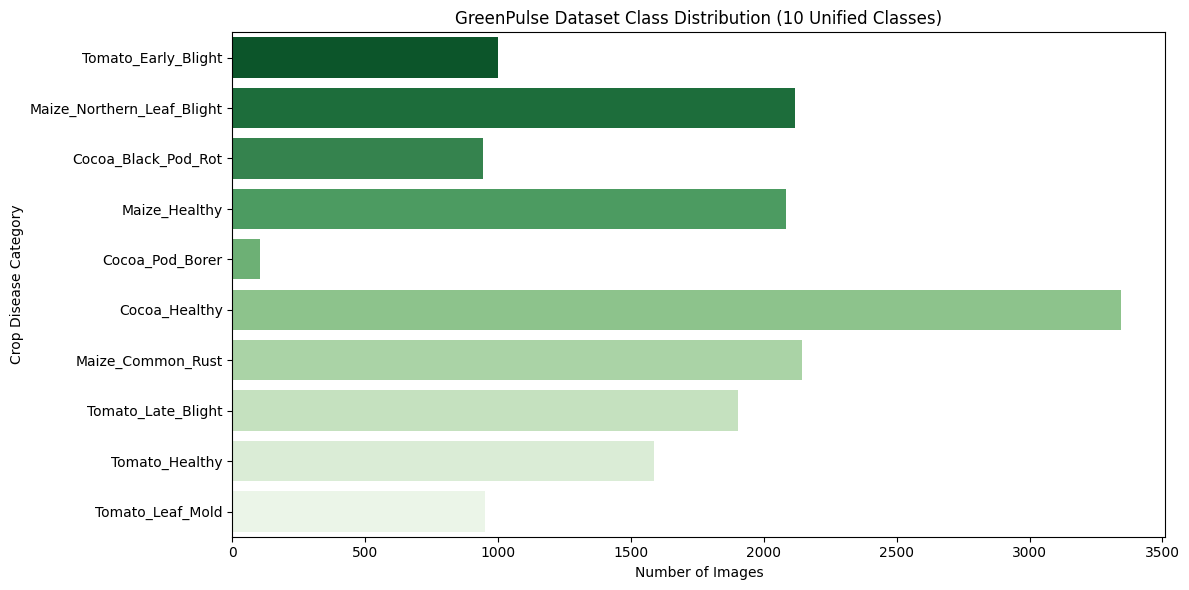

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
%run notebooks/00_data_exploration_and_cleaning.ipynb

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
from pathlib import Path

dataset_path = Path("/content/clean_crop_dataset")
print(dataset_path.exists())

True


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader, Subset


torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Using device: cuda
GPU: Tesla T4


In [5]:
# Augmentating the images to let the model learn from  different versions of
# the same image across epochs.
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# Transform the test data
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# Loading the full dataset
full_dataset = ImageFolder(root=dataset_path, transform=train_transform)

# Then run splits
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Train: 11320
Validation: 2425
Test: 2427


In [8]:
generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    total_size,
    generator=generator
).tolist()

In [9]:
train_indices = indices[:train_size]

val_indices = indices[
    train_size:
    train_size + val_size
]

test_indices = indices[
    train_size + val_size:
]

In [10]:
train_dataset = ImageFolder(
    root=dataset_path,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)

test_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)



In [11]:

train_ds = Subset(
    train_dataset,
    train_indices
)

val_ds = Subset(
    val_dataset,
    val_indices
)

test_ds = Subset(
    test_dataset,
    test_indices
)

In [12]:
# creating the dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [13]:
print("Training images:", len(train_ds))
print("Validation images:", len(val_ds))
print("Test images:", len(test_ds))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training images: 11320
Validation images: 2425
Test images: 2427
Training batches: 354
Validation batches: 76
Test batches: 76


In [14]:
# Checking training batch before training
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([32, 3, 224, 224])
torch.Size([32])


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GreenPulseCustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GreenPulseCustomCNN, self).__init__()

        # Block 1: Input (3, 224, 224) -> (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling & Dropout
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.3)

        # Fully Connected Classifier: 128 * 28 * 28 = 100,352 features
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Feature Extraction
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten
        x = torch.flatten(x, 1)

        # Dense Layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize custom model
NUM_CLASSES = len(train_dataset.classes)
model = GreenPulseCustomCNN(num_classes=NUM_CLASSES).to(device)

print(f"✅ Custom GreenPulse CNN initialized from scratch for {NUM_CLASSES} classes!")

✅ Custom GreenPulse CNN initialized from scratch for 10 classes!


In [16]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = running_loss / total
    accuracy = correct / total
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, accuracy, preds, labels

In [17]:
def fit(model, epochs=5, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"Epoch {epoch:2d}/{epochs} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.3f}")
    return history

In [18]:
custom_model = GreenPulseCustomCNN(num_classes=10).to(device)
history_custom = fit(
    model=custom_model,
    epochs=10,
    lr=1e-3
)


Epoch  1/10 | train loss 1.738 acc 0.698 | val loss 0.412 acc 0.833
Epoch  2/10 | train loss 0.566 acc 0.788 | val loss 0.342 acc 0.858
Epoch  3/10 | train loss 0.510 acc 0.806 | val loss 0.331 acc 0.871
Epoch  4/10 | train loss 0.460 acc 0.827 | val loss 0.314 acc 0.867
Epoch  5/10 | train loss 0.441 acc 0.840 | val loss 0.310 acc 0.881
Epoch  6/10 | train loss 0.433 acc 0.842 | val loss 0.293 acc 0.874
Epoch  7/10 | train loss 0.406 acc 0.847 | val loss 0.245 acc 0.893
Epoch  8/10 | train loss 0.382 acc 0.864 | val loss 0.290 acc 0.878
Epoch  9/10 | train loss 0.381 acc 0.861 | val loss 0.260 acc 0.900
Epoch 10/10 | train loss 0.362 acc 0.872 | val loss 0.222 acc 0.913


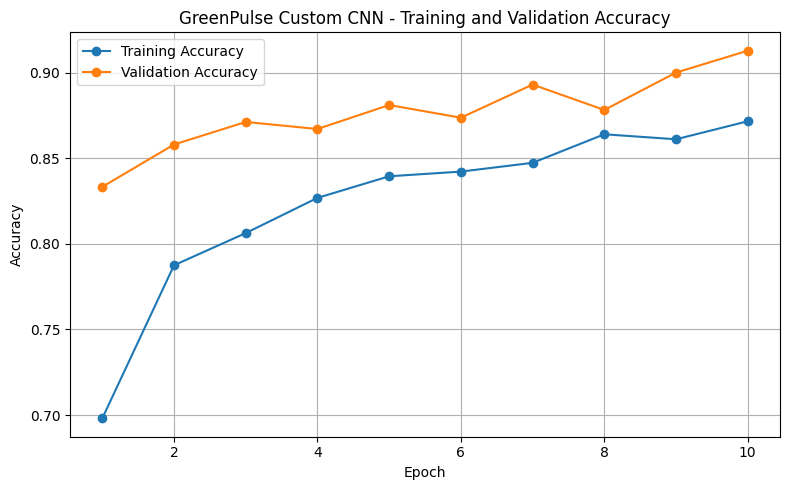

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_custom["train_acc"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_custom["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_custom["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GreenPulse Custom CNN - Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

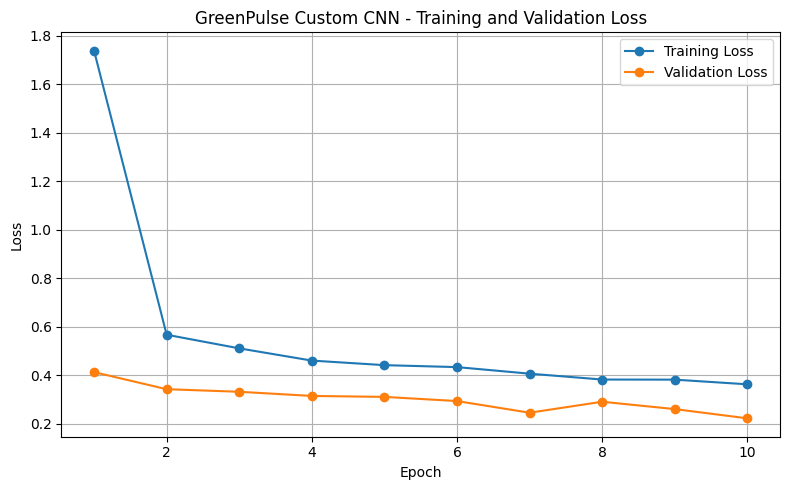

In [20]:
epochs = range(1, len(history_custom["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_custom["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history_custom["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GreenPulse Custom CNN - Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
print(history_custom)

{'train_loss': [1.7378341827712716, 0.5663962646423717, 0.510159508562762, 0.4597338047128684, 0.4409188518465197, 0.4328650841653979, 0.40579363632117904, 0.38157932623536345, 0.38112575329655896, 0.36192421399241204], 'train_acc': [0.6980565371024735, 0.7875441696113075, 0.8063604240282686, 0.8269434628975265, 0.8395759717314487, 0.8423144876325088, 0.8474381625441696, 0.8641342756183745, 0.8612190812720848, 0.8717314487632509], 'val_loss': [0.412098176049203, 0.3417327636418883, 0.33110869402737964, 0.3139578574342826, 0.30998893909847614, 0.292859123533534, 0.2447006953745773, 0.2899722518257259, 0.2596568898810554, 0.22153409705334104], 'val_acc': [0.8334020618556701, 0.8581443298969073, 0.871340206185567, 0.8672164948453608, 0.8812371134020619, 0.8738144329896907, 0.8931958762886598, 0.8783505154639175, 0.9002061855670103, 0.9129896907216495]}


In [22]:
torch.save(custom_model.state_dict(), "custom_greenpulse_model.pth")
print("Custom model trained and saved successfully!")

Custom model trained and saved successfully!


In [23]:
import os

print(os.path.exists("custom_greenpulse_model.pth"))
print(f"Model size: {os.path.getsize('custom_greenpulse_model.pth') / (1024**2):.2f} MB")

True
Model size: 98.38 MB


In [24]:
from google.colab import files

files.download("custom_greenpulse_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>